# Preamble

## Imports & Path

In [1]:
%cd ..

/home/aru/Work/shome2023notebook


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association

In [3]:
sns.set_theme(
    context="talk",
    palette="colorblind",
    style="whitegrid",
)

## Data Loading & Prep


In [4]:
data = pd.read_csv("data/shome2023notebook/annotations.csv")
data.head()

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes,Type
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP,EVAL,RL context. Diagnostic to identify which state...,COMPUTE
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP,EVAL,Check learned weights and bias of model.,INSPECT
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL,MODEL,Defined inside `__init__` method of a neural n...,EQ
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL,MODEL,"Ensure activation tensor is a batch (2D), not ...",SHAPE
4,data/assert_notebooks/H-E-L-P/XID_plus/docs/bu...,"plt.plot(test_x, test_y, 'ro', alpha=0.5)",GH,614,-2.0,NaN,NaN,EXP,EVAL,Visually inspect actual vs. predictions of the...,INSPECT


## Helper Functions

In [5]:
def annot_count_with_percent(ax, orient="v") -> None:
    """Annotate each bar with count and percentage relative to hue size."""
    get_val = (lambda p: p.get_width()) if orient == "h" else (lambda p: p.get_height())
    for container in ax.containers:
        total = sum(get_val(p) for p in container)
        labels = [
            f"{int(get_val(p))} ({100 * get_val(p) / total:.1f}%)"
            for p in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10.0)

In [6]:
def counts(row, col):
    freq = pd.crosstab(row, col)
    pct = pd.crosstab(row, col, normalize="index")
    return freq, pct

In [7]:
def chi2(observed_freq):
    statistic, pvalue, dof, expected_freq = chi2_contingency(observed_freq)

    if dof == 1:
        if (expected_freq < 5).any():
            print("WARNING: Some expected frequencies are less than 5. Chi-square approximation may be invalid.")
    else:
        total = expected_freq.size
        pct_less_than_5 = (expected_freq < 5).sum() / total
        if pct_less_than_5 > 0.20 or (expected_freq < 1).any():
            print("WARNING: More than 20% of expected frequencies are less than 5, or at least one is less than 1. Chi-square approximation may be invalid.")

    cramers_v = association(observed_freq, method="cramer")

    print(f"statistic: {statistic}")
    print(f"pvalue: {pvalue}")
    print(f"dof: {dof}")
    print(f"cramer's v: {cramers_v}")
    print(f"expected_freq:\n{expected_freq}")

In [37]:
def fisher(observed_freq):
    statistic, pvalue = fisher_exact(observed_freq)
    cramers_v = association(observed_freq, method="cramer")
    
    print(f"statistic: {statistic}")
    print(f"pvalue: {pvalue}")
    print(f"cramer's v: {cramers_v}")

# Top-level

We have two categorical dimensions (Intent + sub-type and Stage), and a grouping variable Source.

## Intent x Source

In [8]:
freq, pct = counts(data["source"], data["Intent"])

In [9]:
freq

Intent,EXP,VAL
source,,
GH,263,119
KG,429,4


In [10]:
pct

Intent,EXP,VAL
source,,
GH,0.688482,0.311518
KG,0.990762,0.009238


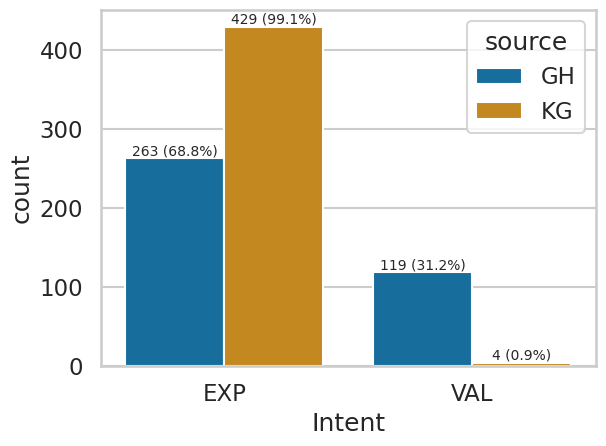

In [11]:
ax = sns.countplot(
    data=data,
    x='Intent',
    order=data["Intent"].value_counts().index,
    hue='source'
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent.pdf")

Are the two populations siginificantly different from one another?

In [12]:
chi2(freq)

statistic: 142.36709812111934
pvalue: 8.083770205966849e-33
dof: 1
cramer's v: 0.4213859836358953
expected_freq:
[[324.34846626  57.65153374]
 [367.65153374  65.34846626]]


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

## Stage x Source

In [13]:
freq, _ = counts(data["source"], data["Stage"])
freq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN,UNC
source,,,,,,,
GH,71,94,49,40,76,50,2
KG,29,77,51,2,253,21,0


There are 2 statements where the stage was unclear (UNC). These are removed prior to the test.

In [14]:
d = data[data["Stage"] != "UNC"]

In [15]:
freq, pct = counts(d["source"], d["Stage"])
freq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
source,,,,,,
GH,71,94,49,40,76,50
KG,29,77,51,2,253,21


In [16]:
pct

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
source,,,,,,
GH,0.186842,0.247368,0.128947,0.105263,0.200000,0.131579
KG,0.066975,0.177829,0.117783,0.004619,0.584296,0.048499


Are the two populations siginificantly different from one another?

In [17]:
chi2(freq)

statistic: 158.0375319815066
pvalue: 2.5927632872693826e-32
dof: 5
cramer's v: 0.4408946679404677
expected_freq:
[[ 46.7404674   79.92619926  46.7404674   19.63099631 153.77613776
   33.18573186]
 [ 53.2595326   91.07380074  53.2595326   22.36900369 175.22386224
   37.81426814]]


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

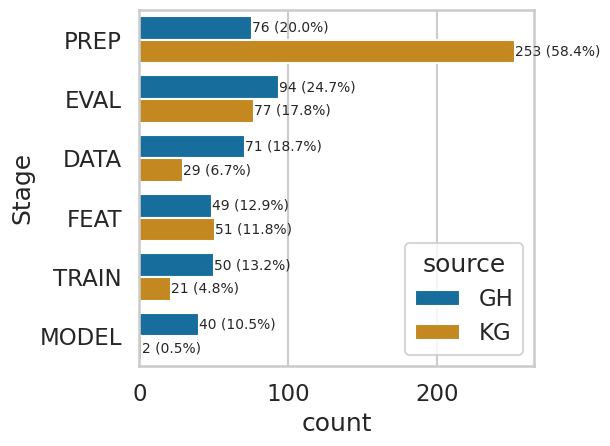

In [18]:
ax = sns.countplot(
    data=d,
    y='Stage',
    order=d["Stage"].value_counts().index,
    hue='source'
)
annot_count_with_percent(ax, orient="h")
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-stage.pdf")

## Intent x Stage

In [25]:
d = data[data["Stage"] != "UNC"]

In [26]:
freq, pct = counts(d["Intent"], d["Stage"])
freq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Intent,,,,,,
EXP,83,148,86,17,305,53
VAL,17,23,14,25,24,18


In [27]:
pct

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Intent,,,,,,
EXP,0.119942,0.213873,0.124277,0.024566,0.440751,0.07659
VAL,0.140496,0.190083,0.115702,0.206612,0.198347,0.14876


Are the two populations siginificantly different from one another?

In [28]:
chi2(freq)

statistic: 87.85909597769994
pvalue: 1.891828148588742e-17
dof: 5
cramer's v: 0.3287366251731897
expected_freq:
[[ 85.11685117 145.5498155   85.11685117  35.74907749 280.03444034
   60.43296433]
 [ 14.88314883  25.4501845   14.88314883   6.25092251  48.96555966
   10.56703567]]


$pvalue < 0.001$ so we reject $H_0$. This means that intent and stage are associated.

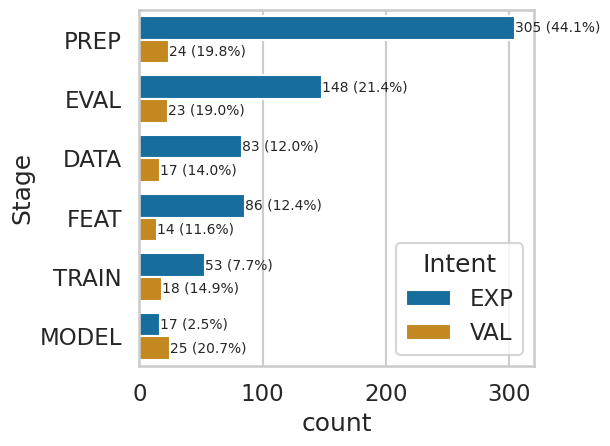

In [30]:
ax = sns.countplot(
    data=d,
    y='Stage',
    order=d["Stage"].value_counts().index,
    hue='Intent'
)
annot_count_with_percent(ax, orient="h")
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-stage-intent.pdf")

But we saw before that intent x source are associated and stage x source are associated. So in intent x stage, source is a confounding variable. We need to perform the test stratified by source.

In [31]:
gh = d[d["source"] == "GH"]
kg = d[d["source"] == "KG"]

In [32]:
ghfreq, ghpct = counts(gh["Intent"], gh["Stage"])
ghfreq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Intent,,,,,,
EXP,54,72,35,16,53,33
VAL,17,22,14,24,23,17


In [41]:
ghpct

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Intent,,,,,,
EXP,0.205323,0.273764,0.133080,0.060837,0.201521,0.125475
VAL,0.145299,0.188034,0.119658,0.205128,0.196581,0.145299


In [34]:
chi2(ghfreq)

statistic: 20.348620358884354
pvalue: 0.0010747724553696286
dof: 5
cramer's v: 0.2314065706595915
expected_freq:
[[49.13947368 65.05789474 33.91315789 27.68421053 52.6        34.60526316]
 [21.86052632 28.94210526 15.08684211 12.31578947 23.4        15.39473684]]


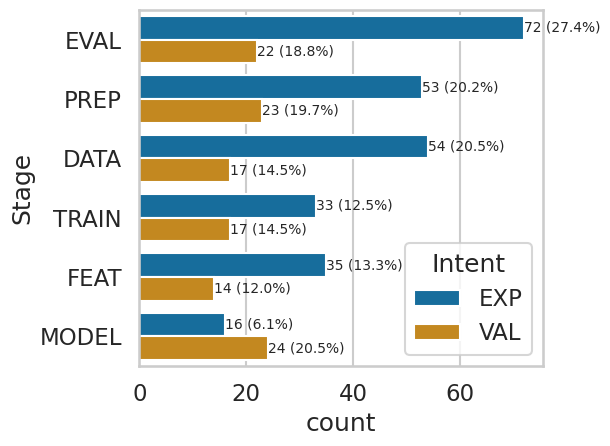

In [42]:
ax = sns.countplot(
    data=gh,
    y='Stage',
    order=gh["Stage"].value_counts().index,
    hue='Intent'
)
annot_count_with_percent(ax, orient="h")
ax.get_figure().tight_layout()
# ax.get_figure().savefig("report/distribution-stage-intent-gh.pdf")

In [33]:
kgfreq, kgpct = counts(kg["Intent"], kg["Stage"])
kgfreq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Intent,,,,,,
EXP,29,76,51,1,252,20
VAL,0,1,0,1,1,1


In [35]:
chi2(kgfreq)

statistic: 57.64599821566226
pvalue: 3.7213664880269596e-11
dof: 5
cramer's v: 0.36487208114898484
expected_freq:
[[2.87321016e+01 7.62886836e+01 5.05288684e+01 1.98152425e+00
  2.50662818e+02 2.08060046e+01]
 [2.67898383e-01 7.11316397e-01 4.71131640e-01 1.84757506e-02
  2.33718245e+00 1.93995381e-01]]


In [38]:
fisher(kgfreq)

statistic: 0.0005664406461858148
pvalue: 0.0086
cramer's v: 0.36487208114898484


## Intent-EXP x Source

In [19]:
d = data[data["Intent"] == "EXP"]

In [20]:
freq, pct = counts(d["source"], d["Type"])
freq

Type,COMPUTE,INSPECT,STATS,STRUCT
source,,,,
GH,82,121,20,40
KG,103,182,58,86


In [21]:
pct

Type,COMPUTE,INSPECT,STATS,STRUCT
source,,,,
GH,0.311787,0.460076,0.076046,0.152091
KG,0.240093,0.424242,0.135198,0.200466


Are the populations significantly different? We apply $X^2$ test since the sample size is large.

In [22]:
chi2(freq)

statistic: 10.769711813259374
pvalue: 0.013038590514346938
dof: 3
cramer's v: 0.12475242426582903
expected_freq:
[[ 70.31069364 115.15751445  29.64450867  47.88728324]
 [114.68930636 187.84248555  48.35549133  78.11271676]]


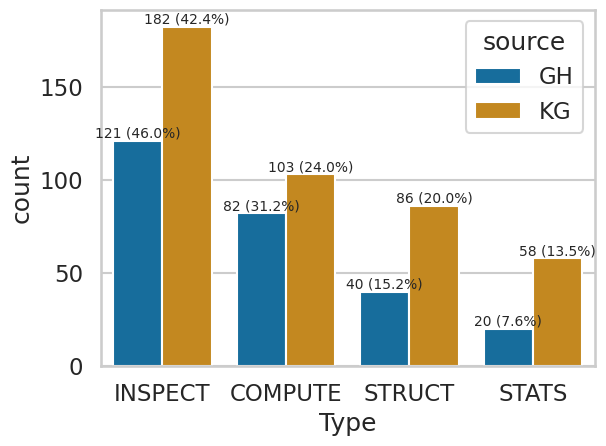

In [23]:
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
    hue="source",
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent-exp.pdf")